In [2]:
import pandas as pd
from google.colab import files
files.upload()
cars_data = pd.read_csv('USA_cars_datasets.csv')
cars_data.head()


Saving USA_cars_datasets.csv to USA_cars_datasets.csv


,Unnamed: 0,price,brand,model,year,title_status,mileage,color,vin,lot,state,country,condition
0,0,6300,toyota,cruiser,2008,clean vehicle,274117.0,black,jtezu11f88k007763,159348797,new jersey,usa,10 days left
1,1,2899,ford,se,2011,clean vehicle,190552.0,silver,2fmdk3gc4bbb02217,166951262,tennessee,usa,6 days left
2,2,5350,dodge,mpv,2018,clean vehicle,39590.0,silver,3c4pdcgg5jt346413,167655728,georgia,usa,2 days left
3,3,25000,ford,door,2014,clean vehicle,64146.0,blue,1ftfw1et4efc23745,167753855,virginia,usa,22 hours left
4,4,27700,chevrolet,1500,2018,clean vehicle,6654.0,red,3gcpcrec2jg473991,167763266,florida,usa,22 hours left


In [3]:
cars_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2499 entries, 0 to 2498
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    2499 non-null   int64  
 1   price         2499 non-null   int64  
 2   brand         2499 non-null   object 
 3   model         2499 non-null   object 
 4   year          2499 non-null   int64  
 5   title_status  2499 non-null   object 
 6   mileage       2499 non-null   float64
 7   color         2499 non-null   object 
 8   vin           2499 non-null   object 
 9   lot           2499 non-null   int64  
 10  state         2499 non-null   object 
 11  country       2499 non-null   object 
 12  condition     2499 non-null   object 
dtypes: float64(1), int64(4), object(8)
memory usage: 253.9+ KB


checking unique values in - brand

In [5]:
cars_data['brand'].unique()

array(['toyota', 'ford', 'dodge', 'chevrolet', 'gmc', 'chrysler', 'kia',
       'buick', 'infiniti', 'mercedes-benz', 'jeep', 'bmw', 'cadillac',
       'hyundai', 'mazda', 'honda', 'heartland', 'jaguar', 'acura',
       'harley-davidson', 'audi', 'lincoln', 'lexus', 'nissan', 'land',
       'maserati', 'peterbilt', 'ram'], dtype=object)

Histogram of car prices

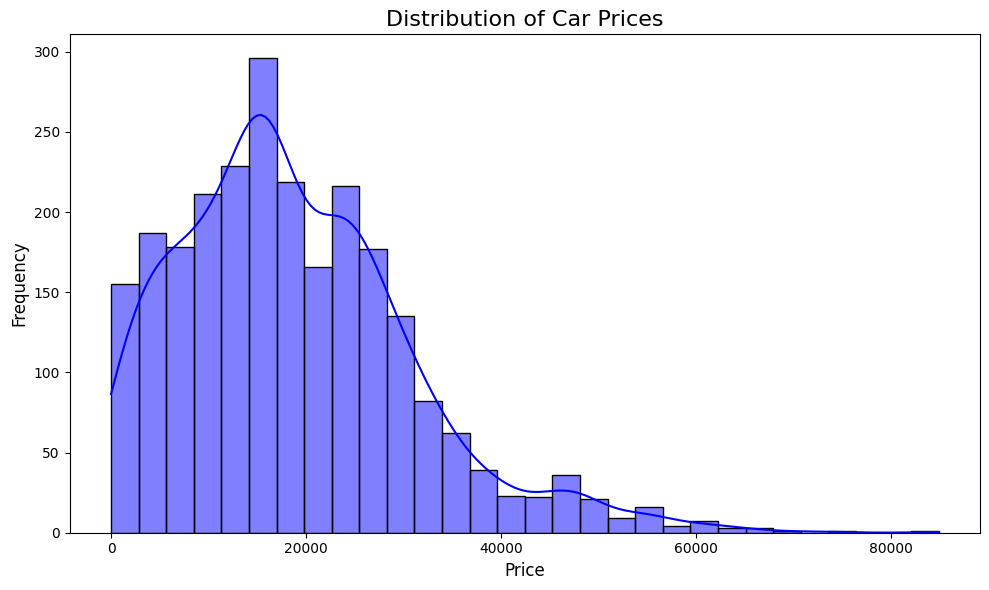

In [8]:

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
plt.figure(figsize=(10, 6))
sns.histplot(cars_data['price'], bins=30, kde=True, color='blue')
plt.title('Distribution of Car Prices', fontsize=16)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()



Box plot of price distribution by top 10 brands

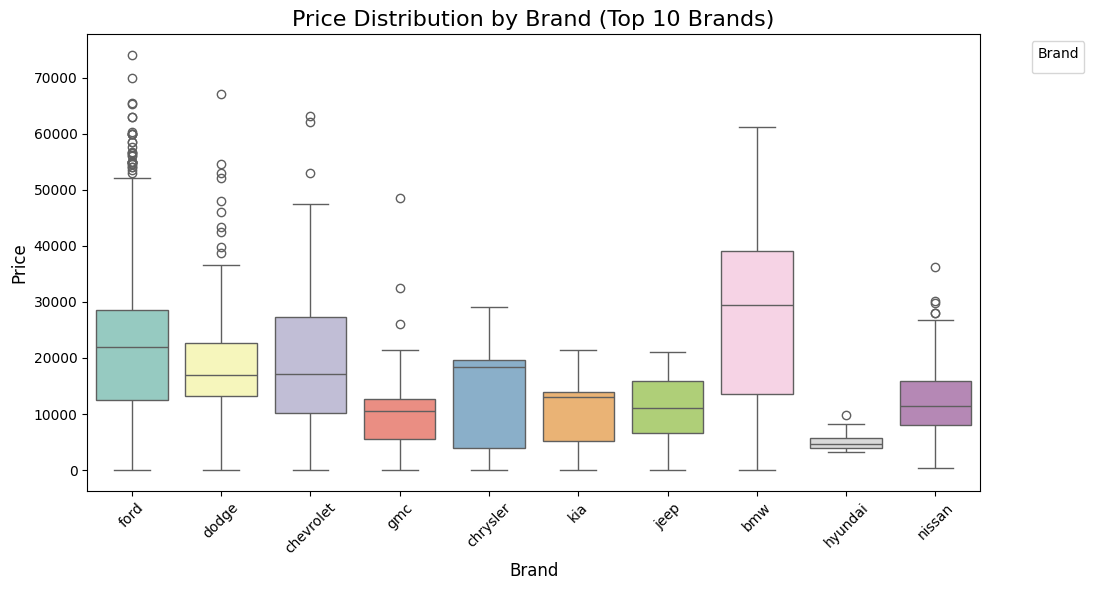

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for the top 10 brands based on the count of cars
top_10_brands = cars_data['brand'].value_counts().head(10).index
top_10_data = cars_data[cars_data['brand'].isin(top_10_brands)]

plt.figure(figsize=(10, 6))
sns.boxplot(data=top_10_data, x='brand', y='price', palette='Set3', hue='brand', dodge=False)
plt.title('Price Distribution by Brand (Top 10 Brands)', fontsize=16)
plt.xlabel('Brand', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend(title='Brand', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



Interactive scatter plot of Price vs Mileage, color-coded by Condition

In [11]:

fig = px.scatter(
    cars_data,
    x='mileage',
    y='price',
    color='condition',
    hover_name='brand',
    title='Price vs. Mileage Scatter Plot',
    labels={'mileage': 'Mileage', 'price': 'Price'},
    size_max=15
)
fig.update_layout(
    xaxis_title="Mileage",
    yaxis_title="Price",
    template="plotly_white"
)
fig.show()



<ipython-input-16-179fb0167ed7>:24: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



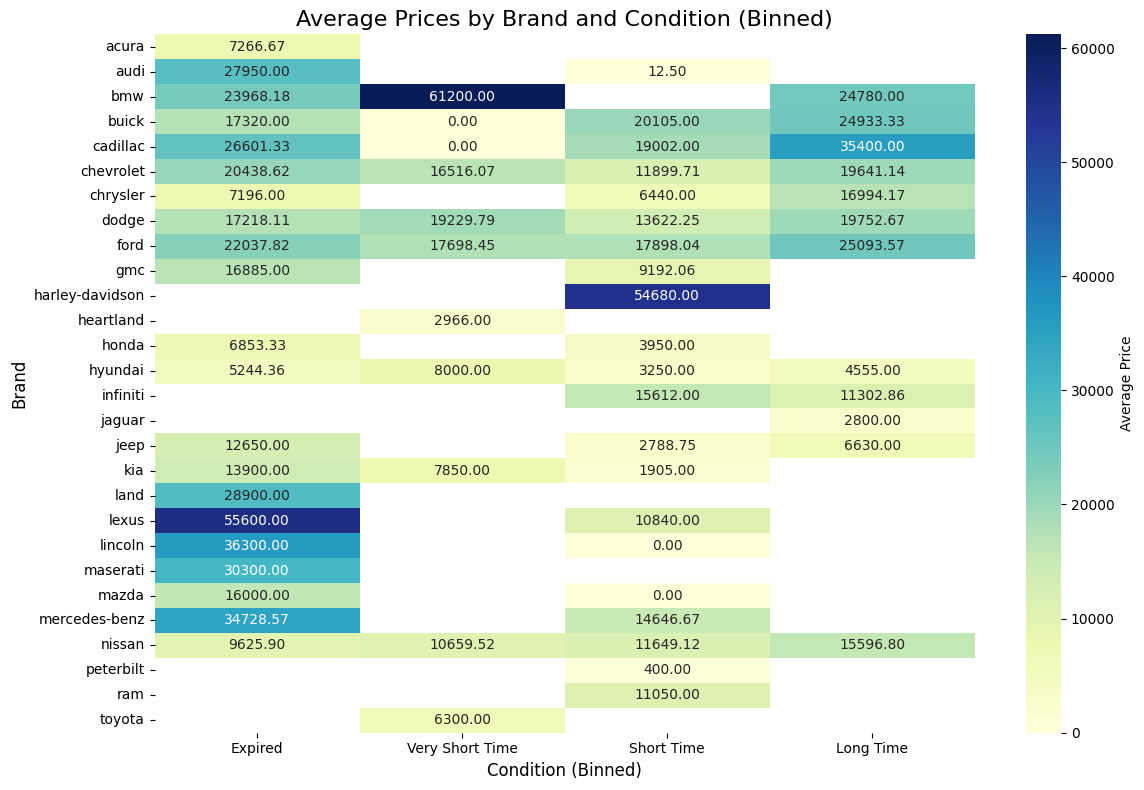

In [16]:

# Function to extract numeric values from the condition column without using `re`
def extract_numeric_condition(condition):
    if isinstance(condition, str):
        # Split the string and try to convert the first part to an integer
        parts = condition.split()
        for part in parts:
            if part.isdigit():  # Check if the part is numeric
                return int(part)
        if "Expired" in condition:
            return 0  # Assign 0 for "Listing Expired"
    return None

# Apply the function to extract numeric values
cars_data['numeric_condition'] = cars_data['condition'].apply(extract_numeric_condition)

# Define bins and labels for the numeric condition column
bins = [0, 5, 10, 20, 100]  # Adjust bins as needed
labels = ['Expired', 'Very Short Time', 'Short Time', 'Long Time']

# Create a binned condition column
cars_data['condition_bin'] = pd.cut(cars_data['numeric_condition'], bins=bins, labels=labels, include_lowest=True)

# Group by brand and binned condition, then calculate average price
heatmap_data = cars_data.groupby(['brand', 'condition_bin'])['price'].mean().unstack()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Average Price'})
plt.title('Average Prices by Brand and Condition (Binned)', fontsize=16)
plt.xlabel('Condition (Binned)', fontsize=12)
plt.ylabel('Brand', fontsize=12)
plt.tight_layout()
plt.show()

